# 🚗 PakWheels Used Cars — End-to-End Machine Learning Price Prediction

## 👤 About the Author

### Abdul Rehman — Data Science & Machine Learning

I am building practical skills in **Python, Data Analysis, Machine Learning, Kaggle, and model deployment** through end-to-end projects.

**Profiles**
- GitHub: `datawithabdulrehman`
- Kaggle: `datawithabxrehman`
- LinkedIn: `datawithabdulrehman`


**Author:** Abdul Rehman


## 1. Import Libraries

In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42
CURRENT_YEAR = 2026

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [ ]:
DATA_PATH = "/content/pakwheels_used_cars_clean.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (9652, 18)


,brand,name,year,vehicle_age,fuel_type,transmission,engine,engine_cc,mileage,mileage_km,price,price_million,currency,image,description,page,source_url,scraped_date
0,Honda,Honda Civic 2007 for sale in Bahawalpur,2007,19,Petrol,Manual,1800cc,1800.0,"130,000 km",130000.0,2200000.0,2.20,PKR,https://cache1.pakwheels.com/ad_pictures/1483/...,Honda Civic 2007 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
1,Honda,Honda Civic 2014 for sale in Bahawalpur,2014,12,Petrol,Automatic,1800cc,1800.0,"121,000 km",121000.0,3500000.0,3.50,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Honda Civic 2014 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
2,Toyota,Toyota Corolla 2011 for sale in Faisalabad,2011,15,Petrol,Manual,1300cc,1300.0,"260,000 km",260000.0,2300000.0,2.30,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Toyota Corolla 2011 for sale in Faisalabad,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
3,Toyota,Toyota Corolla 2011 for sale in Bahawalpur,2011,15,Petrol,Manual,1300cc,1300.0,"150,000 km",150000.0,3000000.0,3.00,PKR,https://cache2.pakwheels.com/ad_pictures/1470/...,Toyota Corolla 2011 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
4,Honda,Honda City 2010 for sale in Rawalpindi,2010,16,Petrol,Manual,1300cc,1300.0,"190,000 km",190000.0,2650000.0,2.65,PKR,https://cache3.pakwheels.com/ad_pictures/1519/...,Honda City 2010 for sale in Rawalpindi,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25


## 3. Initial Dataset Inspection

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())

display(df.head())

Shape: (9652, 18)

Columns:
['brand', 'name', 'year', 'vehicle_age', 'fuel_type', 'transmission', 'engine', 'engine_cc', 'mileage', 'mileage_km', 'price', 'price_million', 'currency', 'image', 'description', 'page', 'source_url', 'scraped_date']

Data Types:


,0
brand,object
name,object
year,int64
vehicle_age,int64
fuel_type,object
transmission,object
engine,object
engine_cc,float64
mileage,object
mileage_km,float64



Missing Values:


,0
engine_cc,152
image,31
source_url,1
page,1
mileage_km,1
mileage,1
currency,1
price_million,1
price,1
description,1



Duplicate Rows: 0


,brand,name,year,vehicle_age,fuel_type,transmission,engine,engine_cc,mileage,mileage_km,price,price_million,currency,image,description,page,source_url,scraped_date
0,Honda,Honda Civic 2007 for sale in Bahawalpur,2007,19,Petrol,Manual,1800cc,1800.0,"130,000 km",130000.0,2200000.0,2.20,PKR,https://cache1.pakwheels.com/ad_pictures/1483/...,Honda Civic 2007 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
1,Honda,Honda Civic 2014 for sale in Bahawalpur,2014,12,Petrol,Automatic,1800cc,1800.0,"121,000 km",121000.0,3500000.0,3.50,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Honda Civic 2014 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
2,Toyota,Toyota Corolla 2011 for sale in Faisalabad,2011,15,Petrol,Manual,1300cc,1300.0,"260,000 km",260000.0,2300000.0,2.30,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Toyota Corolla 2011 for sale in Faisalabad,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
3,Toyota,Toyota Corolla 2011 for sale in Bahawalpur,2011,15,Petrol,Manual,1300cc,1300.0,"150,000 km",150000.0,3000000.0,3.00,PKR,https://cache2.pakwheels.com/ad_pictures/1470/...,Toyota Corolla 2011 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
4,Honda,Honda City 2010 for sale in Rawalpindi,2010,16,Petrol,Manual,1300cc,1300.0,"190,000 km",190000.0,2650000.0,2.65,PKR,https://cache3.pakwheels.com/ad_pictures/1519/...,Honda City 2010 for sale in Rawalpindi,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25


## 4. Data Cleaning

The following steps:
- remove duplicate records
- convert numeric columns safely
- clean text columns
- standardize categorical values
- remove impossible target values
- create useful features such as vehicle age and price in millions


In [ ]:
# Remove duplicates
df = df.drop_duplicates().copy()

# Numeric columns
numeric_cols = ["year", "mileage_km", "engine_cc", "price"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean text columns
text_cols = ["brand", "name", "fuel_type", "transmission"]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        )

# Standardize categorical text
if "fuel_type" in df.columns:
    df["fuel_type"] = df["fuel_type"].str.lower().str.strip()

if "transmission" in df.columns:
    df["transmission"] = df["transmission"].str.lower().str.strip()

# Feature engineering
df["vehicle_age"] = CURRENT_YEAR - df["year"]
df["price_million"] = df["price"] / 1_000_000

# Remove impossible values
df.loc[df["year"] < 1950, "year"] = np.nan
df.loc[df["year"] > CURRENT_YEAR, "year"] = np.nan
df.loc[df["mileage_km"] < 0, "mileage_km"] = np.nan
df.loc[df["engine_cc"] <= 0, "engine_cc"] = np.nan
df.loc[df["price"] <= 0, "price"] = np.nan

# Remove rows where target is unavailable
df = df.dropna(subset=["price"]).copy()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (9651, 18)


,brand,name,year,vehicle_age,fuel_type,transmission,engine,engine_cc,mileage,mileage_km,price,price_million,currency,image,description,page,source_url,scraped_date
0,Honda,Honda Civic 2007 for sale in Bahawalpur,2007.0,19,petrol,manual,1800cc,1800.0,"130,000 km",130000.0,2200000.0,2.20,PKR,https://cache1.pakwheels.com/ad_pictures/1483/...,Honda Civic 2007 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
1,Honda,Honda Civic 2014 for sale in Bahawalpur,2014.0,12,petrol,automatic,1800cc,1800.0,"121,000 km",121000.0,3500000.0,3.50,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Honda Civic 2014 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
2,Toyota,Toyota Corolla 2011 for sale in Faisalabad,2011.0,15,petrol,manual,1300cc,1300.0,"260,000 km",260000.0,2300000.0,2.30,PKR,https://cache4.pakwheels.com/ad_pictures/1522/...,Toyota Corolla 2011 for sale in Faisalabad,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
3,Toyota,Toyota Corolla 2011 for sale in Bahawalpur,2011.0,15,petrol,manual,1300cc,1300.0,"150,000 km",150000.0,3000000.0,3.00,PKR,https://cache2.pakwheels.com/ad_pictures/1470/...,Toyota Corolla 2011 for sale in Bahawalpur,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25
4,Honda,Honda City 2010 for sale in Rawalpindi,2010.0,16,petrol,manual,1300cc,1300.0,"190,000 km",190000.0,2650000.0,2.65,PKR,https://cache3.pakwheels.com/ad_pictures/1519/...,Honda City 2010 for sale in Rawalpindi,1.0,https://www.pakwheels.com/used-cars/search/-/f...,2026-09-25


## 5. Descriptive Statistics

In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,9651,64,Toyota,3256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,9651,3696,Toyota Raize 2021 for sale in Karachi,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,9651.0,NaN,NaN,NaN,2018.46161,6.465472,1965.0,2016.0,2021.0,2023.0,2026.0
vehicle_age,9651.0,NaN,NaN,NaN,7.53839,6.465472,0.0,3.0,5.0,10.0,61.0
fuel_type,9651,7,petrol,7468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,9651,2,automatic,8388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,9651,68,1500cc,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_cc,9429.0,NaN,NaN,NaN,1687.811327,839.434316,658.0,1200.0,1500.0,1800.0,6700.0
mileage,9651,3610,"100,000 km",105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage_km,9651.0,NaN,NaN,NaN,74775.032535,60099.54554,1.0,30000.0,65019.0,103704.0,910000.0


# 📊 6. Exploratory Data Analysis (EDA)

We will examine:
- price distribution
- top brands
- vehicle years
- mileage
- engine size
- fuel type
- transmission
- price relationships
- average price by brand
- correlation between numeric variables


### 6.1 Price Distribution

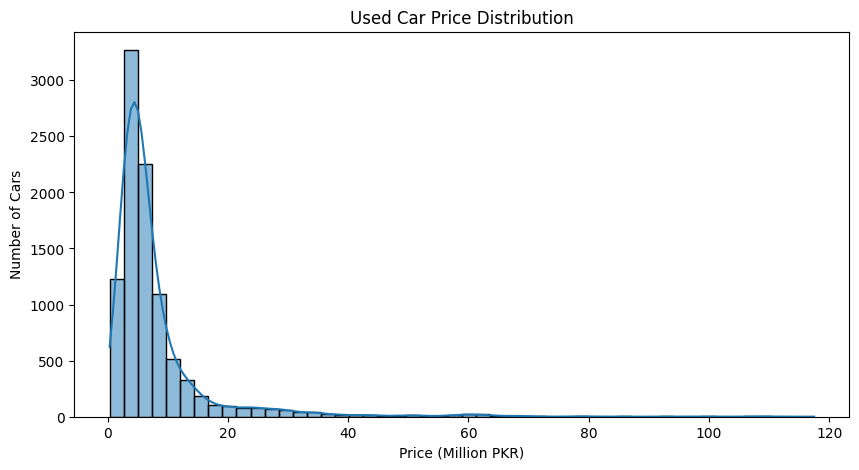

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price_million"].dropna(), bins=50, kde=True)
plt.title("Used Car Price Distribution")
plt.xlabel("Price (Million PKR)")
plt.ylabel("Number of Cars")
plt.show()

### 6.2 Top Brands

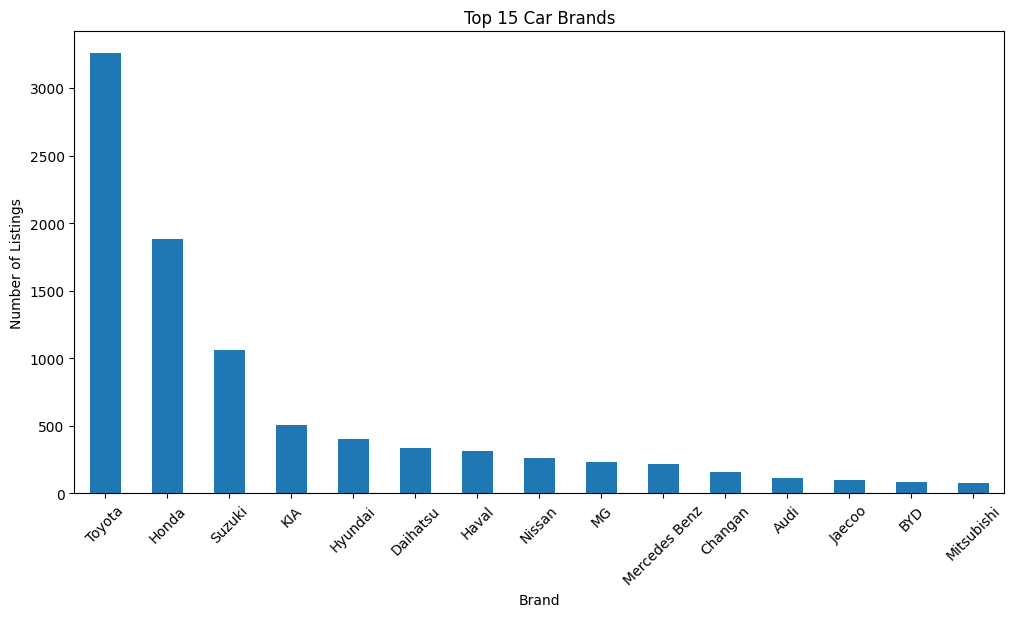

In [ ]:
plt.figure(figsize=(12, 6))
df["brand"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

### 6.3 Vehicle Year Distribution

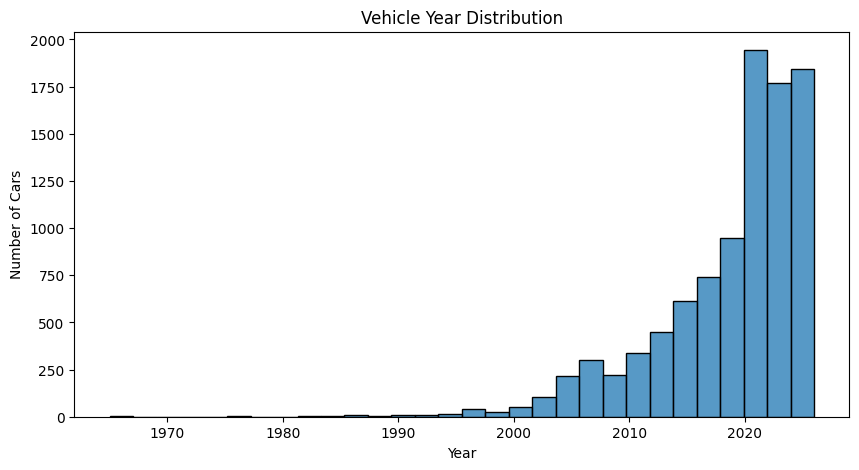

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["year"].dropna(), bins=30)
plt.title("Vehicle Year Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.show()

### 6.4 Mileage Distribution

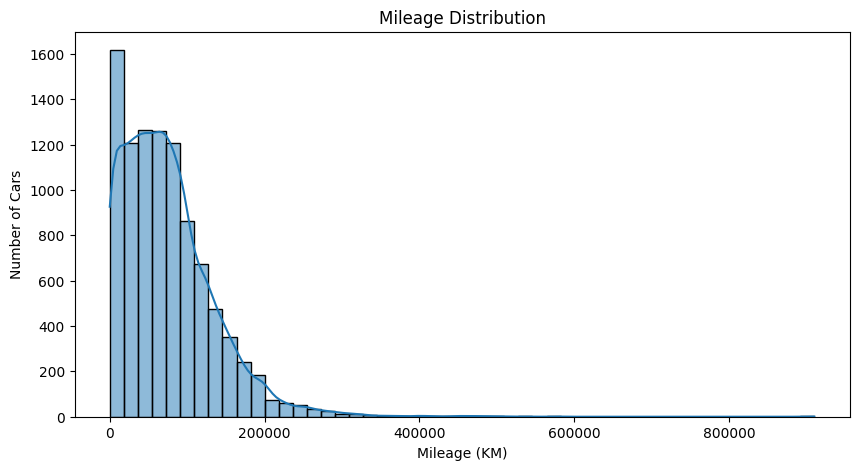

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["mileage_km"].dropna(), bins=50, kde=True)
plt.title("Mileage Distribution")
plt.xlabel("Mileage (KM)")
plt.ylabel("Number of Cars")
plt.show()

### 6.5 Engine Size Distribution

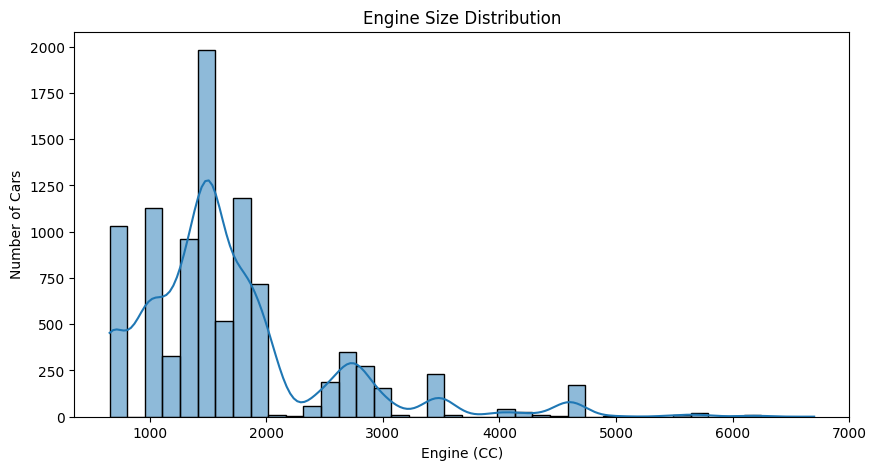

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["engine_cc"].dropna(), bins=40, kde=True)
plt.title("Engine Size Distribution")
plt.xlabel("Engine (CC)")
plt.ylabel("Number of Cars")
plt.show()

### 6.6 Fuel Type

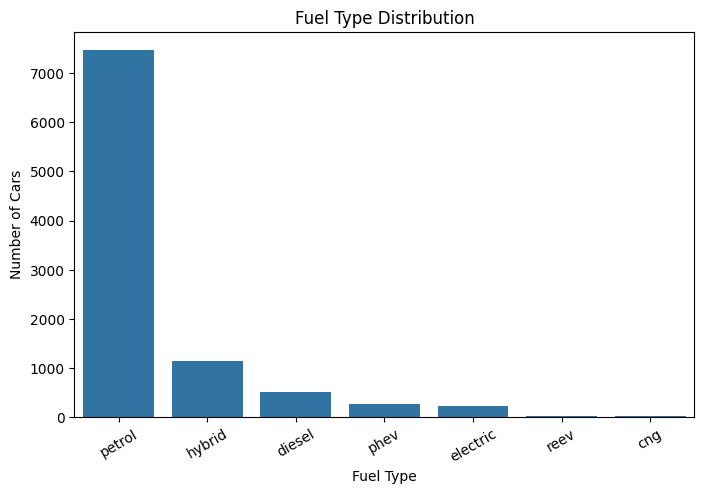

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="fuel_type", order=df["fuel_type"].value_counts().index)
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=30)
plt.show()

### 6.7 Transmission

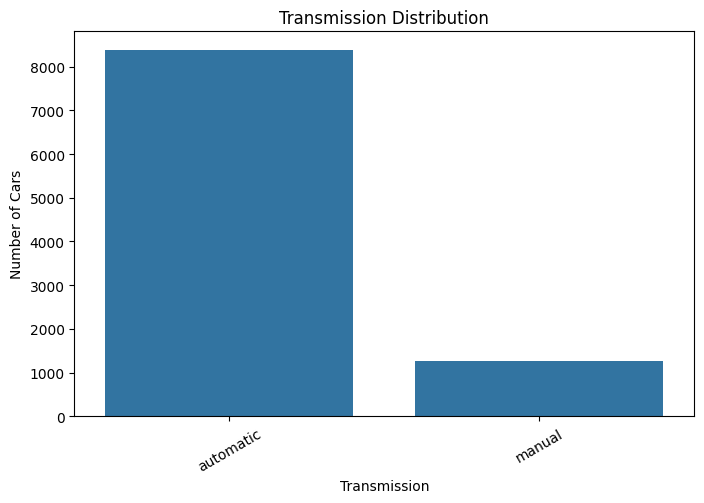

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="transmission", order=df["transmission"].value_counts().index)
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")
plt.xticks(rotation=30)
plt.show()

### 6.8 Price vs Mileage

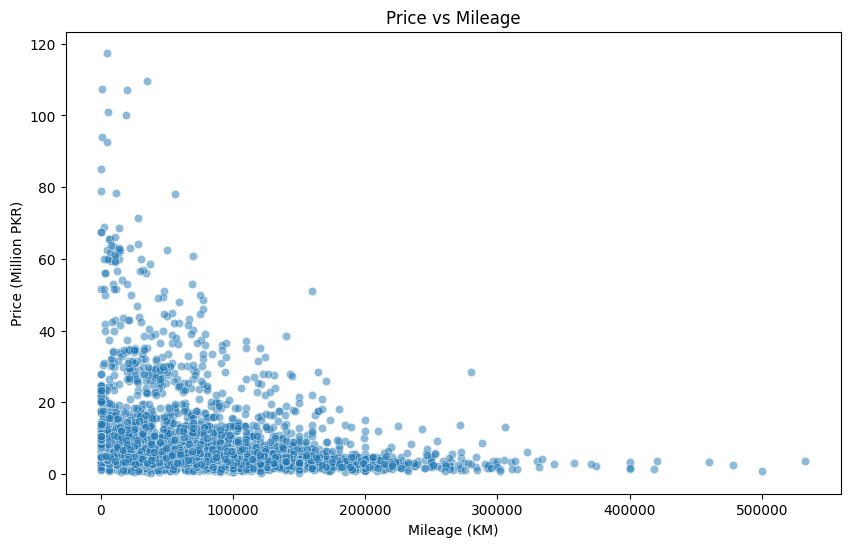

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="mileage_km",
    y="price_million",
    alpha=0.5
)
plt.title("Price vs Mileage")
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (Million PKR)")
plt.show()

### 6.9 Price vs Engine Size

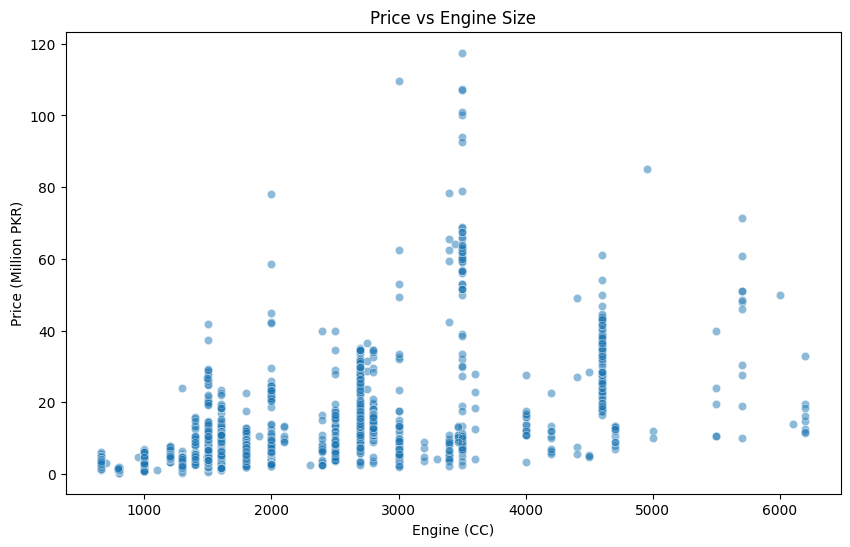

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="engine_cc",
    y="price_million",
    alpha=0.5
)
plt.title("Price vs Engine Size")
plt.xlabel("Engine (CC)")
plt.ylabel("Price (Million PKR)")
plt.show()

### 6.10 Price vs Vehicle Age

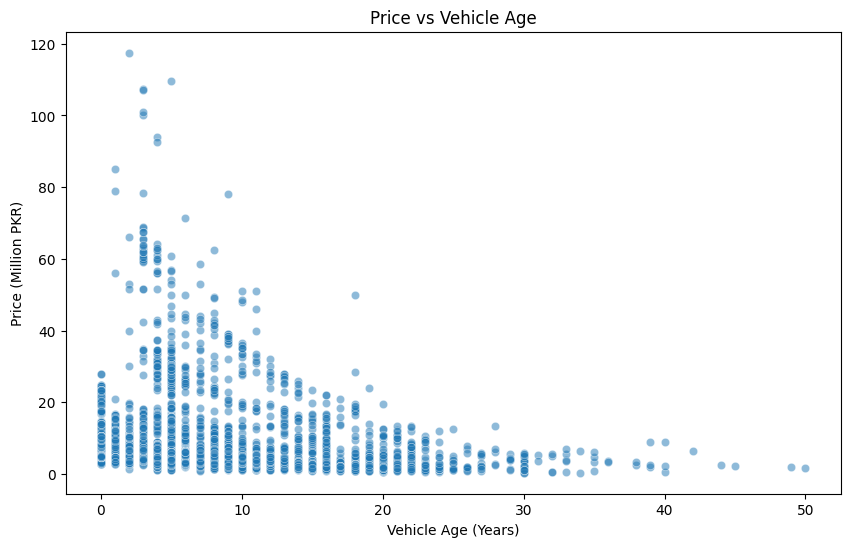

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="vehicle_age",
    y="price_million",
    alpha=0.5
)
plt.title("Price vs Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Price (Million PKR)")
plt.show()

### 6.11 Average Price by Brand

,mean,count
brand,,
Lexus,46.041809,47
Tank,22.665180,61
BMW,22.521491,57
Mercedes Benz,14.837055,219
BYD,13.667230,87
Audi,12.593938,113
Jetour,12.035807,57
Deepal,11.335131,36
Chery,10.623950,56


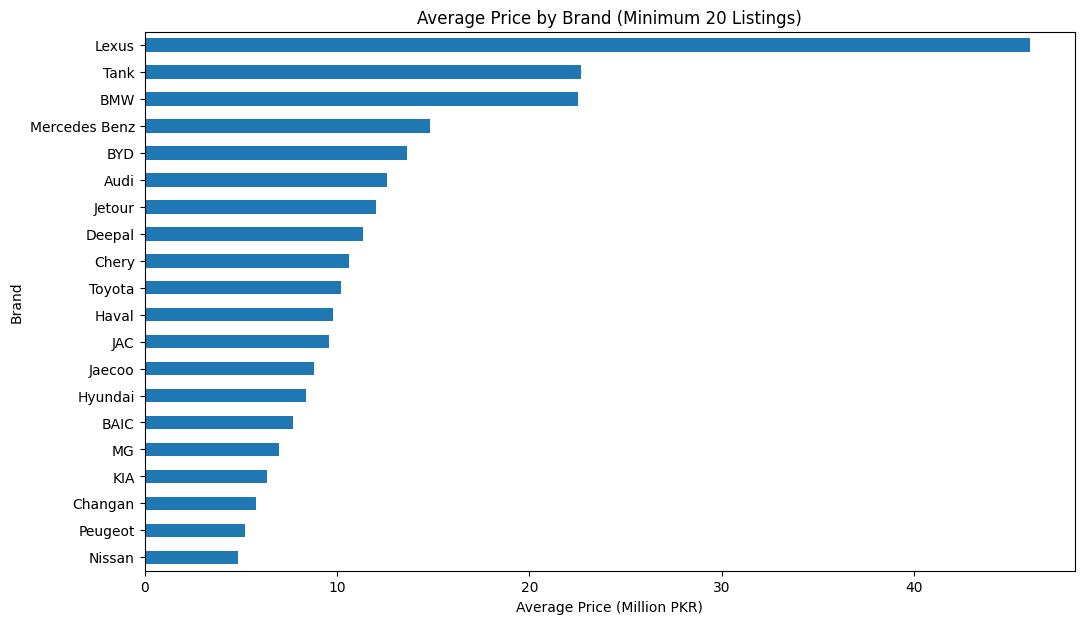

In [ ]:
brand_price = (
    df.groupby("brand")["price_million"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=False)
    .head(20)
)

display(brand_price)

plt.figure(figsize=(12, 7))
brand_price["mean"].sort_values().plot(kind="barh")
plt.title("Average Price by Brand (Minimum 20 Listings)")
plt.xlabel("Average Price (Million PKR)")
plt.ylabel("Brand")
plt.show()

### 6.12 Correlation Heatmap

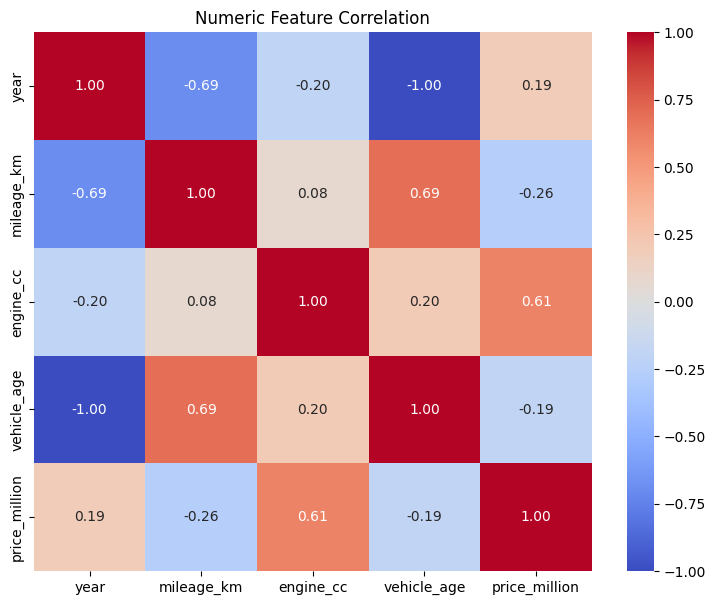

In [ ]:
corr_cols = [
    "year",
    "mileage_km",
    "engine_cc",
    "vehicle_age",
    "price_million"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric Feature Correlation")
plt.show()

# 🤖 7. Machine Learning Preparation

### Target
`price_million`

Using price in millions keeps the regression target numerically well-scaled.

### Features
We use:
- brand
- year
- fuel_type
- transmission
- engine_cc
- mileage_km
- vehicle_age

We deliberately exclude:
- `price`
- `price_million`
- image
- description
- scraped_date

The target-derived `price_million` must never be used as an input feature.


In [ ]:
features = [
    "brand",
    "year",
    "fuel_type",
    "transmission",
    "engine_cc",
    "mileage_km",
    "vehicle_age"
]

target = "price_million"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (9651, 7)
y shape: (9651,)


,brand,year,fuel_type,transmission,engine_cc,mileage_km,vehicle_age
0,Honda,2007.0,petrol,manual,1800.0,130000.0,19
1,Honda,2014.0,petrol,automatic,1800.0,121000.0,12
2,Toyota,2011.0,petrol,manual,1300.0,260000.0,15
3,Toyota,2011.0,petrol,manual,1300.0,150000.0,15
4,Honda,2010.0,petrol,manual,1300.0,190000.0,16


,price_million
0,2.20
1,3.50
2,2.30
3,3.00
4,2.65


## 8. Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7720
Testing samples: 1931


## 9. Preprocessing Pipeline

In [ ]:
numeric_features = [
    "year",
    "engine_cc",
    "mileage_km",
    "vehicle_age"
]

categorical_features = [
    "brand",
    "fuel_type",
    "transmission"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


# 🧠 10. Machine Learning Models

We compare several regression algorithms:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Random Forest Regressor
5. Extra Trees Regressor
6. Gradient Boosting Regressor
7. Support Vector Regression (SVR)

For regression, **SVR** is the correct SVM-based algorithm for predicting continuous prices.


In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    )
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Extra Trees
- Gradient Boosting
- SVR


## 11. Cross-Validation Setup

In [ ]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("5-Fold Cross-Validation ready.")

5-Fold Cross-Validation ready.


## 12. Train and Validate All Models

In [ ]:
results = []

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "Model": name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_R2": scores["test_R2"].mean()
    })

results_df = pd.DataFrame(results).sort_values(
    "CV_RMSE",
    ascending=True
).reset_index(drop=True)

display(results_df)

,Model,CV_MAE,CV_RMSE,CV_R2
0,SVR,1.124676,2.913788,0.904788
1,Extra Trees,1.076456,2.937182,0.902872
2,Random Forest,1.097541,3.038871,0.896939
3,Gradient Boosting,1.510040,3.272228,0.881393
4,Ridge Regression,3.181459,6.160798,0.580301
5,Linear Regression,3.188728,6.162988,0.579983
6,Lasso Regression,3.176936,6.164196,0.579833


## 13. Model Comparison

### Selection rule

Because this is a regression task, the primary validation criterion is:

**Lowest Cross-Validation RMSE**

We also inspect:
- CV MAE
- CV R²

The best model should be selected from the validation results rather than assuming beforehand which algorithm will perform best.


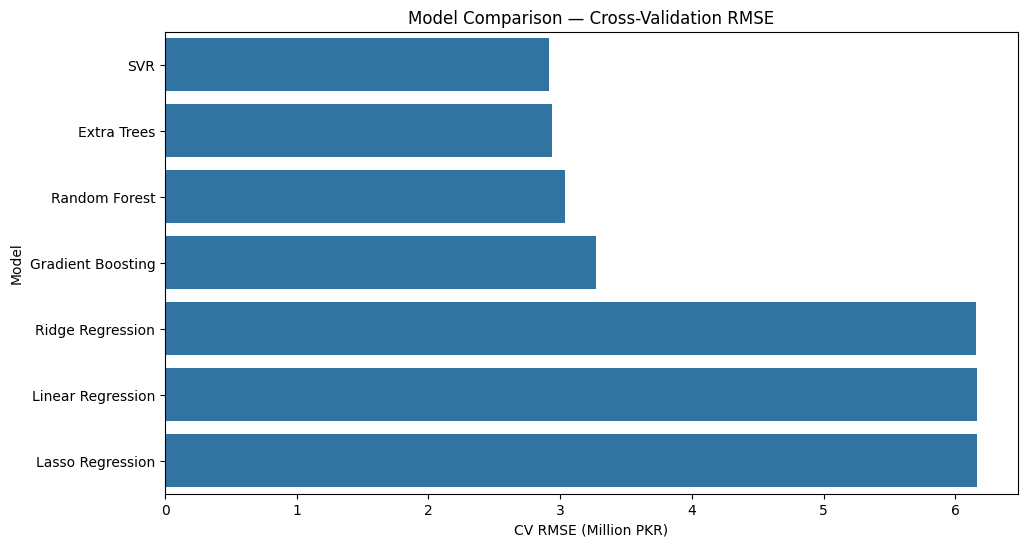

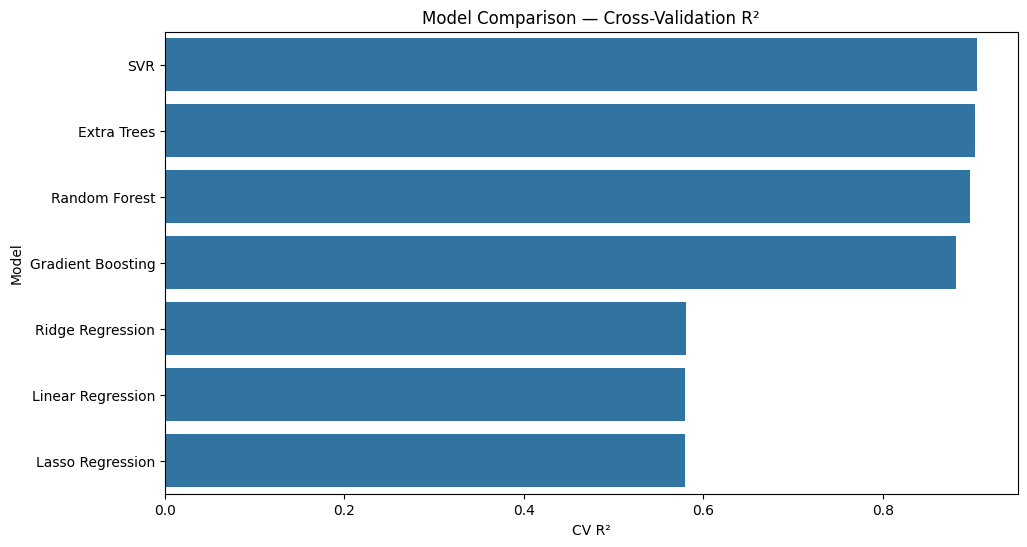

In [ ]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=results_df,
    x="CV_RMSE",
    y="Model"
)
plt.title("Model Comparison — Cross-Validation RMSE")
plt.xlabel("CV RMSE (Million PKR)")
plt.ylabel("Model")
plt.show()

plt.figure(figsize=(11, 6))
sns.barplot(
    data=results_df,
    x="CV_R2",
    y="Model"
)
plt.title("Model Comparison — Cross-Validation R²")
plt.xlabel("CV R²")
plt.ylabel("Model")
plt.show()

## 14. Select Best Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_estimator = models[best_model_name]

print("Selected model:", best_model_name)
print("Selection metric: Lowest 5-Fold CV RMSE")

Selected model: SVR
Selection metric: Lowest 5-Fold CV RMSE


# 🏋️ 15. Train Final Model

Now we train the selected model on the complete training set and evaluate it once on the untouched test set.

This preserves the test set as an independent final evaluation.


In [ ]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_estimator)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred) ** 0.5
test_r2 = r2_score(y_test, y_pred)

print("Final Test Performance")
print("-" * 40)
print(f"MAE  : {test_mae:.4f} million PKR")
print(f"RMSE : {test_rmse:.4f} million PKR")
print(f"R²   : {test_r2:.4f}")

Final Test Performance
----------------------------------------
MAE  : 1.0624 million PKR
RMSE : 2.8679 million PKR
R²   : 0.8995


## 16. Actual vs Predicted

,Actual Price (Million PKR),Predicted Price (Million PKR)
0,3.650,3.518237
1,56.000,52.762710
2,1.360,1.589799
3,8.150,8.356048
4,1.550,1.321766
5,7.375,7.111007
6,2.395,2.332561
7,2.474,2.550448
8,5.350,5.212904
9,2.300,2.272321


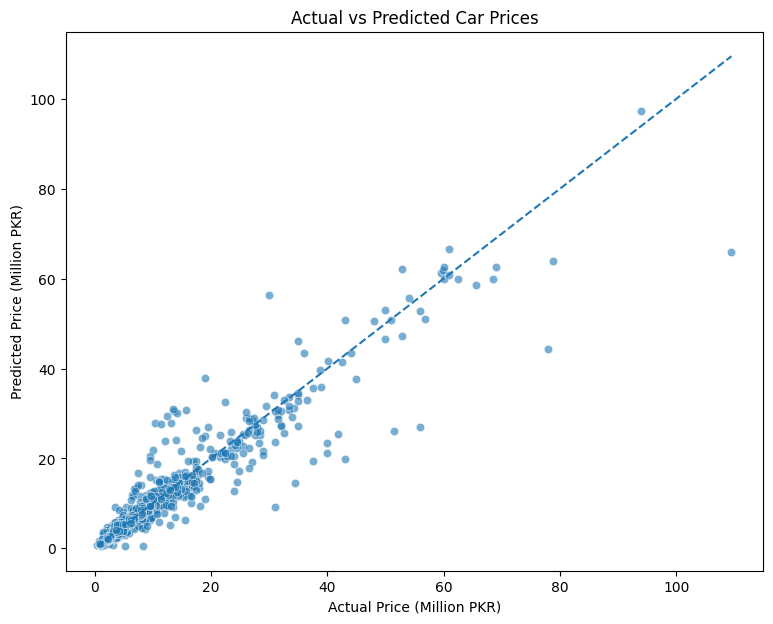

In [ ]:
comparison = pd.DataFrame({
    "Actual Price (Million PKR)": y_test.values,
    "Predicted Price (Million PKR)": y_pred
})

display(comparison.head(20))

plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price (Million PKR)")
plt.ylabel("Predicted Price (Million PKR)")
plt.show()

## 17. Residual Analysis

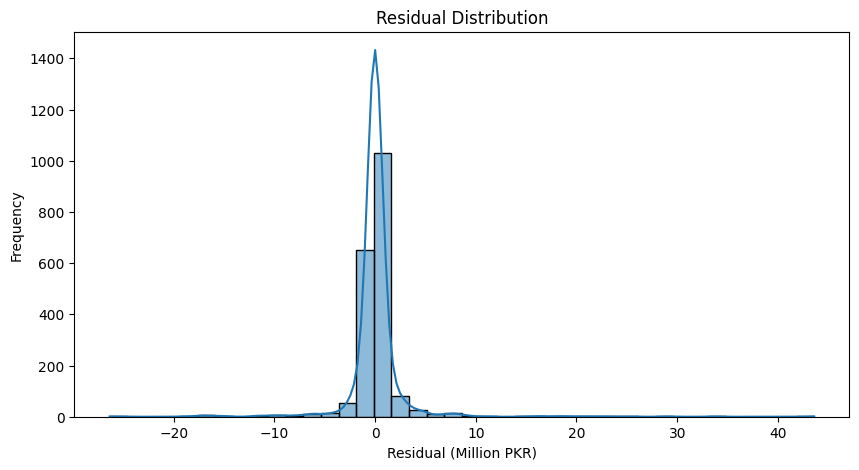

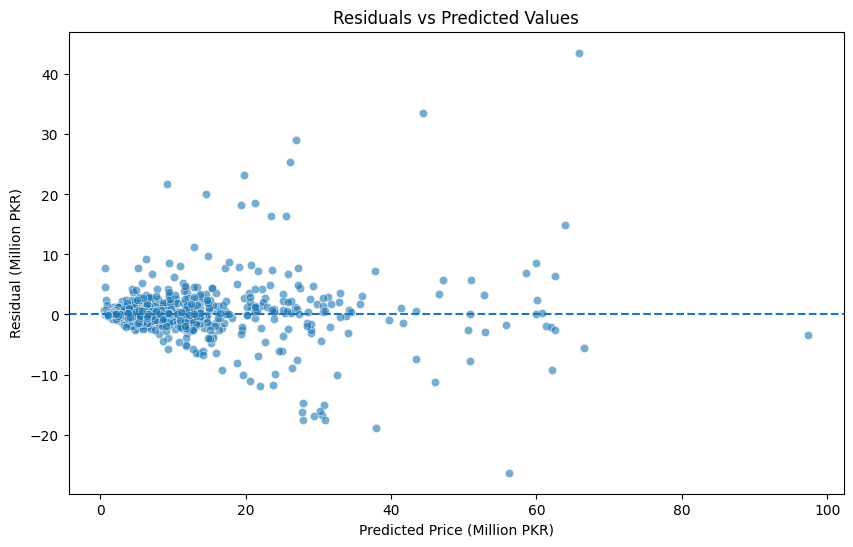

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (Million PKR)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Price (Million PKR)")
plt.ylabel("Residual (Million PKR)")
plt.show()

## 18. Save Model Comparison Results

In [ ]:
results_df.to_csv(
    "pakwheels_model_comparison.csv",
    index=False
)

print("Saved: pakwheels_model_comparison.csv")

Saved: pakwheels_model_comparison.csv


# 💾 19. Save Best Model with Joblib

The complete preprocessing + model pipeline is saved together.

This is important because the deployment application must perform the **same preprocessing** used during training.


In [ ]:
MODEL_PATH = "pakwheels_best_price_model.joblib"

joblib.dump(
    final_pipeline,
    MODEL_PATH
)

print(f"Model saved successfully: {MODEL_PATH}")

Model saved successfully: pakwheels_best_price_model.joblib


## 20. Save Model Metadata

In [ ]:
metadata = {
    "author": "Abdul Rehman",
    "project": "PakWheels Used Cars Price Prediction",
    "target": target,
    "features": features,
    "best_model": best_model_name,
    "test_mae_million_pkr": float(test_mae),
    "test_rmse_million_pkr": float(test_rmse),
    "test_r2": float(test_r2),
    "random_state": RANDOM_STATE
}

joblib.dump(
    metadata,
    "pakwheels_model_metadata.joblib"
)

print("Metadata saved successfully.")

Metadata saved successfully.


## 21. Reload Saved Model

In [ ]:
loaded_model = joblib.load(MODEL_PATH)

print("Saved model loaded successfully!")
print(type(loaded_model))

# 🔮 22. Make a New Car Price Prediction

The function below accepts raw vehicle information and returns the predicted price in PKR.


In [ ]:
def predict_car_price(
    brand,
    year,
    fuel_type,
    transmission,
    engine_cc,
    mileage_km
):
    vehicle_age = CURRENT_YEAR - year

    new_car = pd.DataFrame([{
        "brand": brand,
        "year": year,
        "fuel_type": fuel_type,
        "transmission": transmission,
        "engine_cc": engine_cc,
        "mileage_km": mileage_km,
        "vehicle_age": vehicle_age
    }])

    predicted_million = loaded_model.predict(new_car)[0]
    predicted_pkr = predicted_million * 1_000_000

    return predicted_pkr


# Example prediction
predicted_price = predict_car_price(
    brand="Toyota",
    year=2021,
    fuel_type="petrol",
    transmission="automatic",
    engine_cc=1500,
    mileage_km=50000
)

print(f"Predicted Price: PKR {predicted_price:,.0f}")

# 📋 23. Final Project Report

## Pipeline Summary

**Dataset → Cleaning → Feature Engineering → EDA → Train/Test Split → Preprocessing → 5-Fold Cross-Validation → Model Comparison → Best Model Selection → Final Test Evaluation → Joblib Export → Prediction**

### Models Compared
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Extra Trees
- Gradient Boosting
- Support Vector Regression (SVR)

### Validation Metrics
- MAE
- RMSE
- R²

### Saved Files
- `pakwheels_model_comparison.csv`
- `pakwheels_best_price_model.joblib`
- `pakwheels_model_metadata.joblib`

---

## 🚀 Next Step

The saved `.joblib` pipeline can be connected to a **Streamlit web application**, Flask API, or another deployment system.

**Author:** Abdul Rehman  
**GitHub:** datawithabdulrehman  
**Kaggle:** datawithabxrehman  
**LinkedIn:** datawithabdulrehman
